In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from scipy.optimize import curve_fit

In [11]:
image = np.loadtxt("astro_image (1).csv")

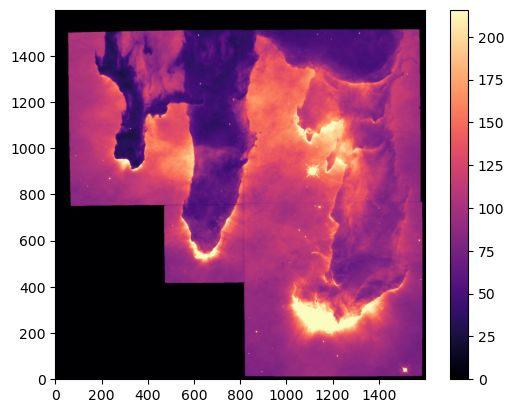

In [26]:
low, high = np.percentile(image, [1, 99])

plt.figure()
im = plt.imshow(image, vmin = low, vmax = high, cmap = "magma", origin = "lower")
plt.colorbar(im)

In [13]:
np.shape(image)

(1600, 1600)

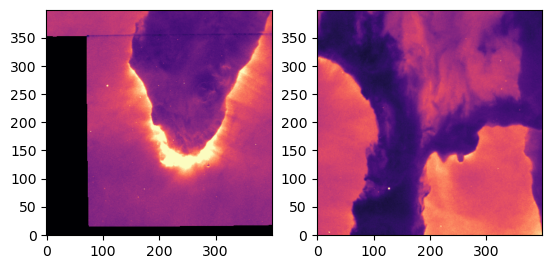

In [27]:
fit, ax = plt.subplots(1, 2)
ax[0].imshow(image[400:800,400:800], vmin = low, vmax = high, cmap = "magma", origin = "lower")
ax[1].imshow(image[1000:1400,200:600], vmin = low, vmax = high, cmap = "magma", origin = "lower")

In [80]:
df = pd.read_csv('ramen-ratings.csv')

1) What are the column names in this dataset?

In [81]:
df.columns

Index(['Review #', 'Brand', 'Variety', 'Style', 'Country', 'Stars', 'Top Ten'], dtype='object')

The column names are review #, brand, variety, style, country, stars, and top ten. 

2) What is the ramen style of the 27th entry?

In [82]:
print(df.loc[26, "Style"])

Pack


pack

3. How many different ramen brands are there?

In [83]:
df['Brand'].value_counts()

Brand
Nissin      381
Nongshim     98
Maruchan     76
Mama         71
Paldo        66
           ... 
Omachi        1
Haioreum      1
Sutah         1
Tung-I        1
Westbrae      1
Name: count, Length: 355, dtype: int64

355 ramen brands

4. Sort the dataset by brand names.

In [84]:
df.sort_values(by='Brand')

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
229,2351,1 To 3 Noodles,Chatpat Masala,Pack,India,4,NaN
456,2124,7 Select,Nissin Instant Noodles Tom Yum Seafood Creamy ...,Bowl,Thailand,3.5,NaN
463,2117,7 Select,Nissin Instant Noodles Shrimp Ma Nao Lui Suan ...,Bowl,Thailand,4,NaN
877,1703,7 Select/Nissin,Super Tom Yum Shrimp,Cup,Thailand,3.5,NaN
911,1669,A-One,Mi Ly Instant Noodles Mi Chay Vegetarian Flavor,Cup,Vietnam,1.25,NaN
...,...,...,...,...,...,...,...
823,1757,iMee,Instant Noodles Beef Flavour,Pack,Netherlands,3.25,NaN
662,1918,iMee,Instant Noodles chicken Flavour,Pack,Netherlands,3.5,NaN
797,1783,iMee,Instant Noodles Creamy Tom Yum Shrimp Flavour,Pack,Netherlands,4.5,NaN
2135,445,iNoodle,Taiwan Style Chow Mein,Pack,Taiwan,2.25,NaN


5. How many ramen brands are made in the USA?

In [101]:
usa_brands = df[df["Country"] == "USA"]
usa_brand = usa_brands["Brand"].nunique()
usa_brand

49

49 ramen brands are made in the USA

6. How many ramen brands in the USA make pack-style ramen?

In [105]:
is_usa = df["Country"] == "USA"
is_pack = df["Style"] == "Pack"
is_filter = df[is_usa & is_pack]
creative_name = is_filter["Brand"].nunique()
creative_name

27

27 ramen brands in the USA make pack-style ramen

In [42]:
table = Table.read("global_CCl4_MM.dat", format='ascii')

In [66]:
df = Table.to_pandas(table)

In [67]:
df.columns

Index(['CCl4ottoyr', 'CCl4ottomon', 'CCl4ottoNHm', 'CCl4ottoNHsd',
       'CCl4ottoSHm', 'CCl4ottoSHsd', 'CCl4ottoGLm', 'CCl4ottoGLsd'],
      dtype='object')

In [68]:
df["date"] = df["CCl4ottoyr"] + (df["CCl4ottomon"] - 1) / 12

df = df.rename(columns = {
    "CCl4ottoGLm": "global mean concentration",
    "CCl4ottoGLsd": "global mean concentration sd"
})

In [69]:
new_df = df.dropna()

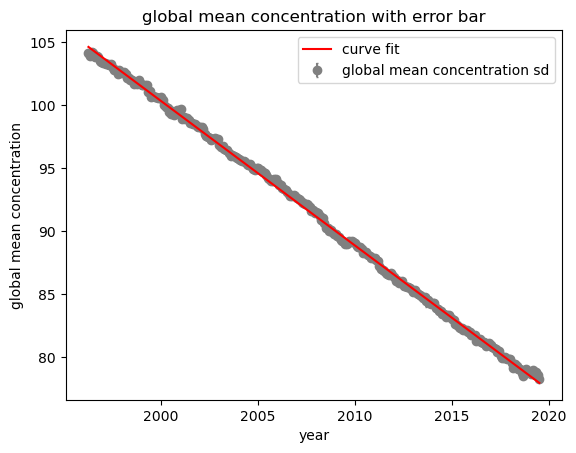

In [77]:
def model(m, x, b):
    return m*x + b

x = new_df["date"].values
y = new_df["global mean concentration"].values
z = new_df["global mean concentration sd"].values

p0 = [1, 1]
popt, pcov = curve_fit(model, x, y, p0=p0)
A_fit, k_fit = popt
f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)"
residuals = y - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof

plt.figure()
plt.errorbar(x, y, yerr=z, fmt='o', capsize=1, label='global mean concentration sd', zorder = 1, color = "grey")
plt.plot(x, model(x, A_fit, k_fit), label = "curve fit", color = "red", zorder = 2)

plt.xlabel('year')
plt.ylabel('global mean concentration')
plt.title('global mean concentration with error bar')
plt.legend()
plt.show()